### Step 1: Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split

### Step 2: Read and Analysis Data

In [3]:
data = pd.read_csv('./data/DOGE-USD.csv')

In [4]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


In [6]:
data.corr(numeric_only=True)

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


In [8]:
data['Date'] = pd.to_datetime(data['Date'])

In [10]:
data.set_index('Date', inplace=True)

In [29]:
data.isnull().sum()

Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [30]:
data = data.dropna()

In [31]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


Text(0.5, 1.0, 'Date vs Close of 2021')

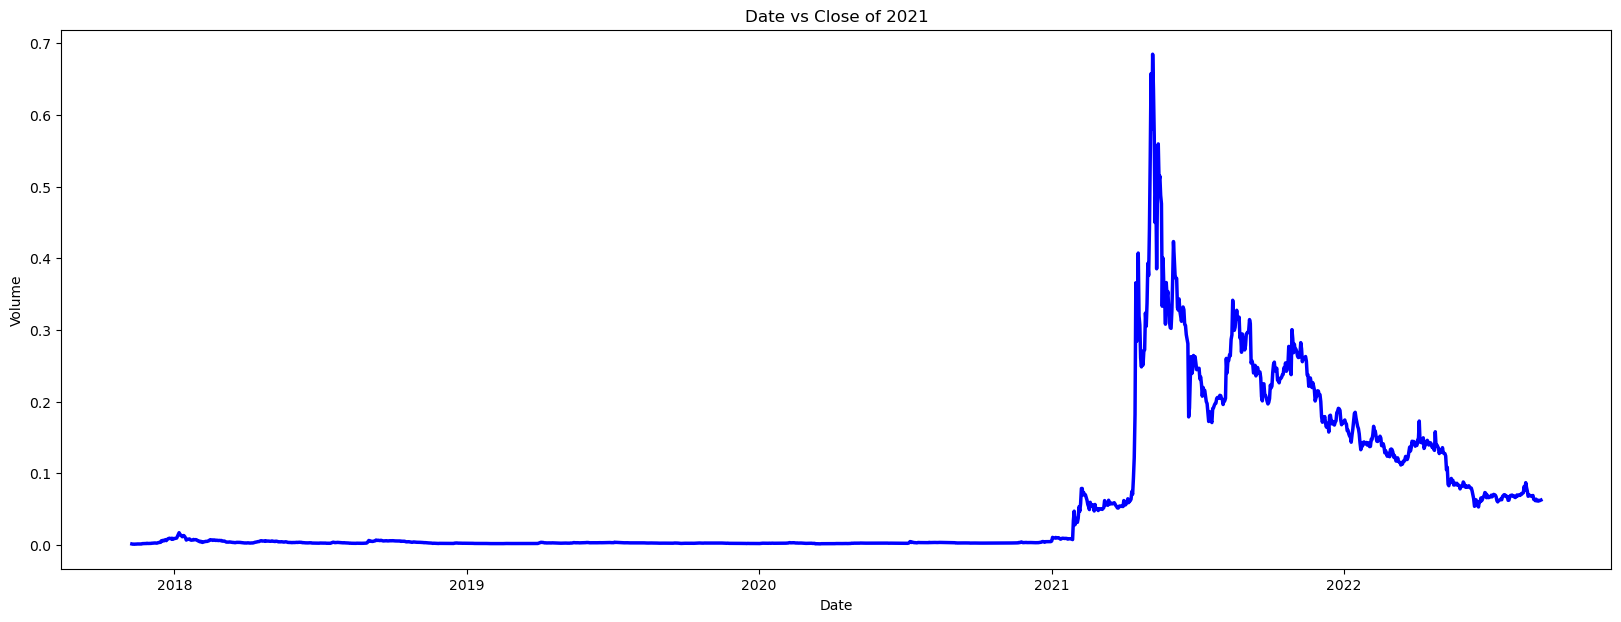

In [36]:
plt.figure(figsize=(20, 7))
x = data['Close']
plt.plot(x, linewidth=2.5, color='b')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title("Date vs Close of 2021")

### Step 3: Define Factor

In [37]:
data['gap'] = (data['High'] - data['Low']) * data['Volume']
data['y'] = data['High'] / data['Volume']
data['z'] = data['Low'] / data['Volume']
data['a'] = data['High'] / data['Low']
data['b'] = (data['High'] / data['Low']) * data['Volume']

In [43]:
data.corr()

,Open,High,Low,Close,Adj Close,Volume,gap,y,z,a,b
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850,0.352990,-0.060605,-0.060225,0.167513,0.421422
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321,0.426831,-0.071289,-0.071516,0.213999,0.493106
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991,0.306753,-0.051917,-0.050553,0.125759,0.384806
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678,0.383333,-0.063868,-0.063251,0.172057,0.456479
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678,0.383333,-0.063868,-0.063251,0.172057,0.456479
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000,0.876107,-0.157106,-0.160179,0.495372,0.953900
gap,0.352990,0.426831,0.306753,0.383333,0.383333,0.876107,1.000000,-0.082279,-0.085274,0.410915,0.912234
y,-0.060605,-0.071289,-0.051917,-0.063868,-0.063868,-0.157106,-0.082279,1.000000,0.998282,-0.106365,-0.131614
z,-0.060225,-0.071516,-0.050553,-0.063251,-0.063251,-0.160179,-0.085274,0.998282,1.000000,-0.127435,-0.134609
a,0.167513,0.213999,0.125759,0.172057,0.172057,0.495372,0.410915,-0.106365,-0.127435,1.000000,0.597434


In [42]:
abs(data.corr()['Close']).sort_values(ascending=False)

Close        1.000000
Adj Close    1.000000
High         0.995104
Low          0.994575
Open         0.992514
Volume       0.588678
b            0.456479
gap          0.383333
a            0.172057
y            0.063868
z            0.063251
Name: Close, dtype: float64

### Step 4: Preparing Data

In [51]:
X_data = data[['Volume', 'gap', 'a', 'b']]
y_data = data[['Close']]

In [78]:
X_train = X_data[-30:-19]
X_test = X_data[-19:]
y_train = y_data[-30:-19]
y_test = y_data[-19:]

### Step 5: Model Development

In [79]:
model = SARIMAX(
    endog=y_train, 
    exog=X_train,
    order=(2, 1, 1),
    freq='D'
)

E:\software\miniconda3\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [80]:
results = model.fit()

E:\software\miniconda3\envs\ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
E:\software\miniconda3\envs\ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [81]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                   11
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  47.663
Date:                Sat, 24 Jan 2026   AIC                            -79.326
Time:                        02:32:40   BIC                            -76.905
Sample:                    08-05-2022   HQIC                           -81.981
                         - 08-15-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Volume      7.491e-10   1.84e-10      4.077      0.000    3.89e-10    1.11e-09
gap          1.13e-08   2.45e-09      4.615      0.000     6.5e-09    1.61e-08
a             -0.0073   5.05e-15  -1.44e+12      0.000      -0.007      -0.007
b          -7.541e-10   1.83e-10     -4.126      0.000   -1.11e-09   -3.96e-10
ar.L1              -0   8.45e-15         -0      1.000   -1.66e-14    1.66e-14
ar.L2               0   2.59e-14          0      1.000   -5.07e-14    5.07e-14
ma.L1         -0.5015   1.87e-14  -2.68e+13      0.000      -0.501      -0.501
sigma2      3.673e-07   5.67e-08      6.481      0.000    2.56e-07    4.78e-07
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 0.51
Prob(Q):                              0.70   Prob(JB):                         0.77
Heteroskedasticity (H):               0.40   Skew:                            -0.54
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.41e+30. Standard errors may be unstable.
"""

In [82]:
start = 11
end = 29
predictions = results.predict(
    start=start,
    end=end,
    exog=X_test)

### Step 6: Plot Result

<Axes: xlabel='Date'>

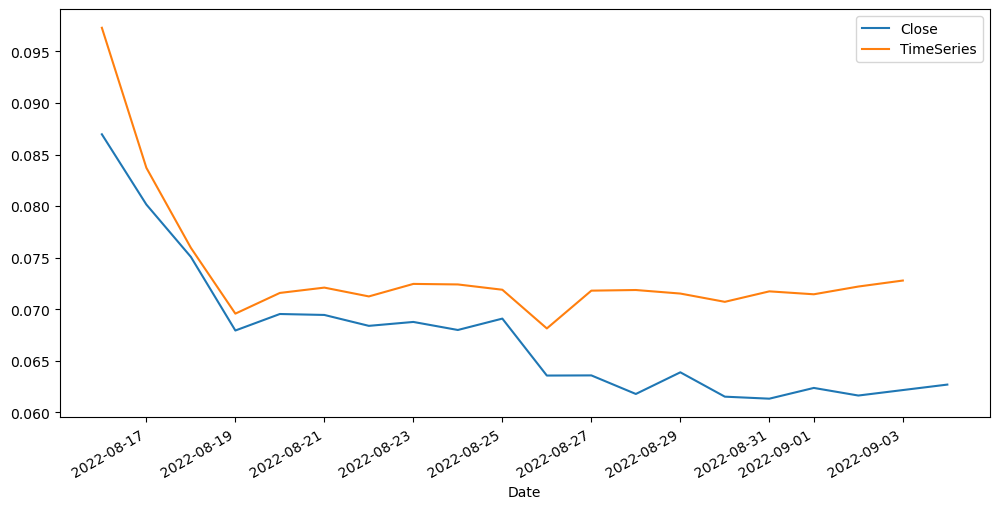

In [83]:
y_test.plot(legend=True, figsize=(12, 6))
predictions.plot(label='TimeSeries', legend=True)